# Triggering with a threshold on channel
Para este módulo se 

## Libraries and FPGA image

We need the additional functionality of *numpy* and *matplotlib* for data plotting and faster array operations.

In [1]:
import time
import numpy as np
from matplotlib import pyplot as plt
from rp_overlay import overlay
import rp

# Nuevas fuentes
RP_TRIG_SRC_CHAB_PE = 14
RP_TRIG_SRC_CHAB_NE = 15

# Que quiere decir el 6? (Mensaje de error?)
rp.rp_Init()


0

In [4]:
# FPGA, qué hace overlay()
fpga = overlay()


Time taken to load BIN is 157.000000 Milli Seconds
BIN FILE loaded through FPGA manager successfully
Load overlay [OK].


In [6]:
fpga.status()

False

In [2]:
dir(fpga)

NameError: name 'fpga' is not defined

In [22]:
print(fpga.fpgapath)

print(fpga.overlay)

print(fpga.overlays)

print(fpga.__weakref__)

/opt/redpitaya/fpga
v0.94
/sys/kernel/config/device-tree/overlays
None


In [8]:
dir(rp)

['AA',
 'ADC_BUFFER_SIZE',
 'BB',
 'DAC_BUFFER_SIZE',
 'KK',
 'OUT_TR_ADC',
 'OUT_TR_DAC',
 'PP',
 'RISE_FALL_MAX_RATIO',
 'RISE_FALL_MIN_RATIO',
 'RP_AC',
 'RP_AIN0',
 'RP_AIN1',
 'RP_AIN2',
 'RP_AIN3',
 'RP_AOUT0',
 'RP_AOUT1',
 'RP_AOUT2',
 'RP_AOUT3',
 'RP_BTS',
 'RP_CH_1',
 'RP_CH_2',
 'RP_CH_3',
 'RP_CH_4',
 'RP_DC',
 'RP_DEC_1',
 'RP_DEC_1024',
 'RP_DEC_128',
 'RP_DEC_16',
 'RP_DEC_16384',
 'RP_DEC_2',
 'RP_DEC_2048',
 'RP_DEC_256',
 'RP_DEC_32',
 'RP_DEC_32768',
 'RP_DEC_4',
 'RP_DEC_4096',
 'RP_DEC_512',
 'RP_DEC_64',
 'RP_DEC_65536',
 'RP_DEC_8',
 'RP_DEC_8192',
 'RP_DIO0_N',
 'RP_DIO0_P',
 'RP_DIO1_N',
 'RP_DIO1_P',
 'RP_DIO2_N',
 'RP_DIO2_P',
 'RP_DIO3_N',
 'RP_DIO3_P',
 'RP_DIO4_N',
 'RP_DIO4_P',
 'RP_DIO5_N',
 'RP_DIO5_P',
 'RP_DIO6_N',
 'RP_DIO6_P',
 'RP_DIO7_N',
 'RP_DIO7_P',
 'RP_EABA',
 'RP_ECMD',
 'RP_EFCB',
 'RP_EFOB',
 'RP_EFRB',
 'RP_EFWB',
 'RP_EIPV',
 'RP_ELID',
 'RP_EMMD',
 'RP_EMNC',
 'RP_EMRO',
 'RP_ENN',
 'RP_EOED',
 'RP_EOMD',
 'RP_EOOR',
 'RP_EPN',
 'RP_EU

## Macros
Throughout this tutorial we will mention macros multiple times. Here is a complete list of macros that will come in handy when customising this notebook. The marcos are a part of the **rp** library.

- **Decimation** - RP_DEC_1, RP_DEC_2, RP_DEC_4, RP_DEC_8, RP_DEC_16, RP_DEC_32, RP_DEC_64, RP_DEC_128, RP_DEC_256, RP_DEC_512, RP_DEC_1024, RP_DEC_2048, RP_DEC_4096, RP_DEC_8192, RP_DEC_16384, RP_DEC_32768, RP_DEC_65536

- **Acquisition trigger** - RP_TRIG_SRC_DISABLED, RP_TRIG_SRC_NOW, RP_TRIG_SRC_CHA_PE, RP_TRIG_SRC_CHA_NE, RP_TRIG_SRC_CHB_PE, RP_TRIG_SRC_CHB_NE, RP_TRIG_SRC_EXT_PE, RP_TRIG_SRC_EXT_NE, RP_TRIG_SRC_AWG_PE, RP_TRIG_SRC_AWG_NE,

  **NEW:** RP_TRIG_SRC_CHAB_PE= 14, RP_TRIG_SRC_CHAB_NE=15


- **Acquisition trigger state** - RP_TRIG_STATE_TRIGGERED, RP_TRIG_STATE_WAITING
- **Buffer size** - ADC_BUFFER_SIZE, DAC_BUFFER_SIZE
- **Fast analog channels** - RP_CH_1, RP_CH_2

SIGNALlab 250-12 only:
- **Input coupling** - RP_DC, RP_AC

STEMlab 125-14 4-Input only:
- **Fast analog channels** - RP_CH_3, RP_CH_4
- **Acquisition trigger** - RP_TRIG_SRC_CHC_PE, RP_TRIG_SRC_CHC_NE, RP_TRIG_SRC_CHD_PE, RP_TRIG_SRC_CHD_NE


## Trigger level

For the purposes of demonstartion we will first generate a signal on Red Pitaya's outputs and then acquire it on the inputs. The so-called "loopback" does not have many applications in practice, but is perfect for this demonstration. In practice, an external signal is applied directly to the Red Pitaya's inputs.

In [113]:
# Generator parameters
channel = rp.RP_CH_1
waveform = rp.RP_WAVEFORM_SINE

channel2 = rp.RP_CH_2
waveform2 = rp.RP_WAVEFORM_DC

freq = 100000
ampl = 1.0
dc_amp = 0

# Acquisition paramters
dec = rp.RP_DEC_1
trig_lvl = 0.5
trig_dly = 0    # se tiene que especificar 

# Posedge en A y B
acq_trig_sour = 14
#acq_trig_sour = rp.RP_TRIG_SRC_CHA_PE # 2

print(acq_trig_sour)

N = int(16384)

14


Above are the parameters for the generation and acquisition. We set the acquisition trigger to IN1 positive edge 0.5 V.

### Generación 
Now, we are going to reset both acquisition and generation parameters and configure the generator.

In [121]:
rp.rp_GenReset()
rp.rp_AcqReset()

###### Generation #####

# OUT1
print("Gen_start")
rp.rp_GenWaveform(channel2, waveform)
rp.rp_GenFreqDirect(channel2, freq)
rp.rp_GenAmp(channel2, ampl)

# OUT2
rp.rp_GenWaveform(channel, waveform2)
rp.rp_GenAmp(channel, dc_amp)



# Specify generator trigger source
# Source for generator, no tengo que especificar los trigger de ambos canales?
rp.rp_GenTriggerSource(channel, rp.RP_GEN_TRIG_SRC_INTERNAL)

# Enable output synchronisation
rp.rp_GenOutEnableSync(True)

Gen_start


0

Here comes the new part - Configuring the acquisition parameters.

In [122]:
##### Acquisition #####
# Set Decimation
rp.rp_AcqSetDecimation(rp.RP_DEC_1)

# Set trigger level and delay for both channels
rp.rp_AcqSetTriggerLevel(rp.RP_T_CH_1, trig_lvl)
rp.rp_AcqSetTriggerDelay(trig_dly)

rp.rp_AcqSetTriggerLevel(rp.RP_T_CH_2, trig_lvl)
rp.rp_AcqSetTriggerDelay(trig_dly)

0

After configuring the acquisition parameters, we need to start the acquisition and set the acquisition trigger source. The order of the two commands is extremely important here! **Acquisition must be started before the acquisition trigger is specified!**

In [123]:
# Start Acquisition
print("Acq_start")
rp.rp_AcqStart()
time.sleep(0.1)
# Specify trigger - input 1 positive edge
rp.rp_AcqSetTriggerSrc(acq_trig_sour)
time.sleep(0.1)

Acq_start


Now, we will trigger the acquisition (by triggering the generator), and acquire the data.


In [124]:
# Triggers the generator or the acquisition? 
rp.rp_GenTriggerOnly(channel)       # Trigger generator
rp.rp_GenTriggerOnly(channel2)       # Trigger generator

# Trigger state
while 1:
    trig_state = rp.rp_AcqGetTriggerState()[1]
    if trig_state == rp.RP_TRIG_STATE_TRIGGERED:
        break
# Fill state
while 1:
    if rp.rp_AcqGetBufferFillState()[1]:
        break


## Debería tener cuatro canales
# CH1 -DC 
# Volts
fbuff = rp.fBuffer(N)
res = rp.rp_AcqGetOldestDataV(rp.RP_CH_1, N, fbuff)[1]


# CH2 - DC 
# Volts
fbuff_2 = rp.fBuffer(N)
res_2 = rp.rp_AcqGetOldestDataV(rp.RP_CH_2, N, fbuff_2)[1]


With *rp_AcqGetTriggerState()* and *rp_AcqGetBufferFillState()*, we are checking the second returned parameter (the first one is function execution success).

After confirming that the trigger condition was met and that the data buffer is full, the data can be acquired from the Red Pitaya. We can use either of the two presented functions, depending on whether we want RAW data or Volts directly.

Next, we will convert the data to a numpy array for easy plotting.

In [125]:
X = np.arange(0, N, 1)

data_V = np.zeros(N, dtype = float)
data_raw = np.zeros(N, dtype = int)

data_V_2 = np.zeros(N, dtype = float)
data_raw_2 = np.zeros(N, dtype = int)

# Por qué hacemos esto? Entiendo que podría utilizar directamente buff.
for i in range(0, N, 1):
    data_V[i] = fbuff[i]

# Por qué hacemos esto? Entiendo que podría utilizar directamente buff.
for i in range(0, N, 1):
    data_V_2[i] = fbuff_2[i]

Text(0.5, 1.0, 'CH 2')

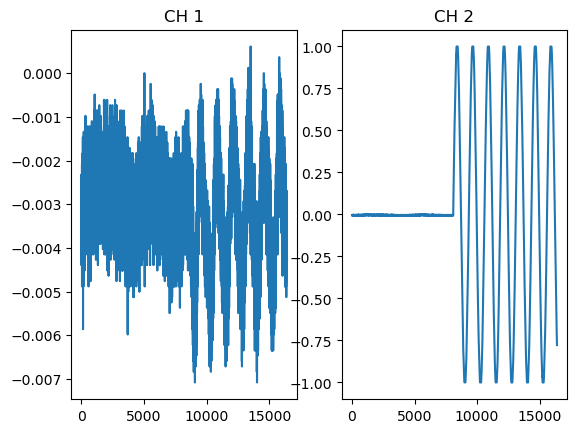

In [126]:
figure, axis = plt.subplots(1, 2) 

axis[0].plot(X, data_V) 
axis[0].set_title("CH 1")

axis[1].plot(X, data_V_2) 
axis[1].set_title("CH 2") 


And here is the data we have been looking for, nicely displayed in a graph. As you can see from the X-axis, Red Pitaya returns a 16384-sample long buffer of acquired data. The triggering moment is in the middle, around the 8192th sample (the trigger delay is 0), so half the data was acquired before the trigger and half the data after it. If the transition events are not what we are looking for, we can increase the trigger delay to get more data points after the triggering moment or decrease it (negative numbers) to get more information before the triggering event.

### Note
There are a lot of different commands for the Acquisition. The list of available functions is quite an achievement to read through, so from now on, please refer to the *C and Python API section* of the [Command table](https://redpitaya.readthedocs.io/en/latest/appsFeatures/remoteControl/command_list.html#list-of-supported-scpi-api-commands) for all available commands.
